In [17]:
#testing the ODEsolving etc.

In [18]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp

In [43]:
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC*D_0*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr*Tr_0*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8 * T8_0*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
    
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param = params
def cancer_ode_parametrised(t,y):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)


In [44]:
C0 = [0.4,4e-4,3e-4,5e-4,1.5e-3]
tspan = (0.0,200.0,)

In [45]:
sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

In [46]:
from matplotlib import pyplot as plt

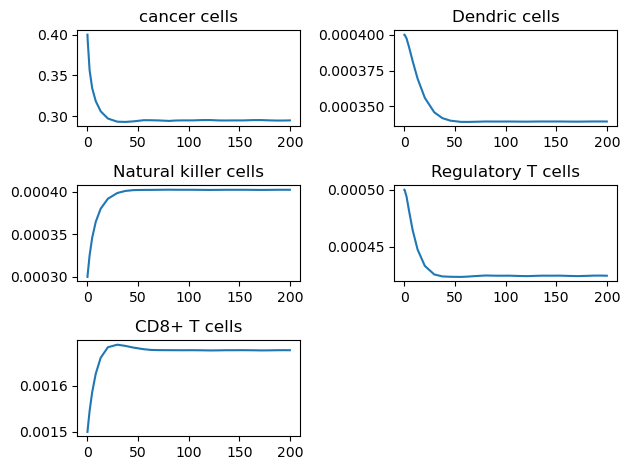

In [47]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [94]:
# SDEs
import sdeint
from sdeint import itoint
from sdeint import itoEuler

# need a noise term
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.0,0.2]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param,noise_NK_prod = params
def cancer_ode_parametrised(y,t):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,(1-noise_NK_prod)*sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)
def G(y,t):
    C,D,N,Tr,T8 = y
    return np.diag((noise_param*lambda_C*C*(1-C/C_M),0,noise_NK_prod*sigma_N,0,0,))

In [95]:
t = np.arange(tspan[0],tspan[1],0.001)
sol = itoEuler(cancer_ode_parametrised, G, C0, t)

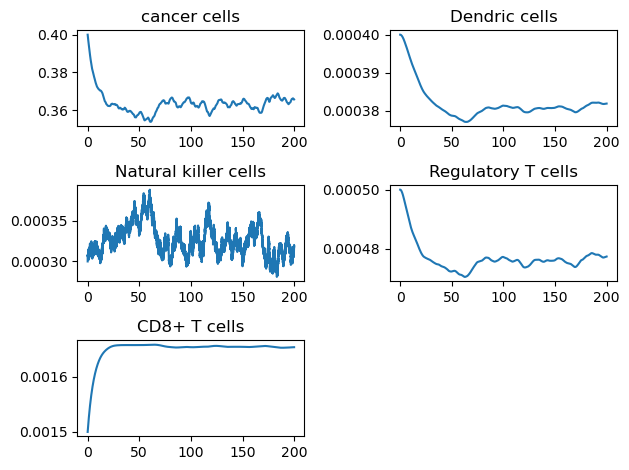

In [96]:
y = []
i = 0
for i in range(sol.shape[1]):
    y.append(sol[:,i])
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()
